# Hypothesis testing

## Exercise 1

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
from scipy.stats import chi2

In [13]:
# Importing data
data_1  = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/data/LLH_Ratio_2_data.txt', delim_whitespace = True, header = None)
data_2  = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/data/LLH_Ratio_2a_data.txt', delim_whitespace = True, header = None)

data_1 = data_1[0]
data_2 = data_2[0]

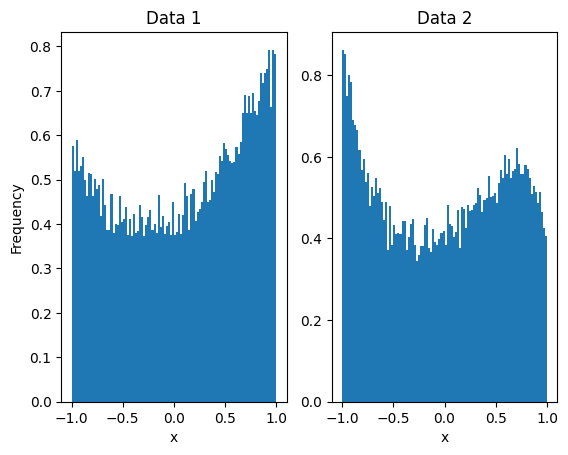

In [17]:
# Plotting the data
plt.subplot(1, 2, 1)
plt.hist(data_1, bins = 100, density = True)
plt.title('Data 1')
plt.xlabel('x')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(data_2, bins = 100, density = True)
plt.title('Data 2')
plt.xlabel('x');

In [22]:
x_min, x_max = -1, 1

def null_hypothesis(rho, omega, x):
    return 1 + rho * x + omega * x**2

def alternative_hypothesis(rho, omega, gamma, x):
    return 1 + rho * x + omega * x**2 + gamma * x**5

# Calculating the ln-likelihood ratio to calculate the p-value
def ln_likelihood_ratio(data, rho, omega, gamma):
    null_hypothesis_values = null_hypothesis(rho, omega, data)
    alternative_hypothesis_values = alternative_hypothesis(rho, omega, gamma, data)

    return -2 * np.log(alternative_hypothesis_values / null_hypothesis_values)

# Calculating the p-value
def p_value(data, rho, omega, gamma):
    ln_likelihood_ratio_value = ln_likelihood_ratio(data, rho, omega, gamma)

    p_value = 1 - chi2.cdf(ln_likelihood_ratio_value, 1)
    return p_value

TypeError: minimize_neg_log_likelihood() missing 1 required positional argument: 'omega'